<a href="https://colab.research.google.com/github/sunnysavita10/Complete-LLM-Finetuning/blob/main/Knowledge_DIstillation_in_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
# ----- Dataset (MNIST) -----
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=1000)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.13MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.8MB/s]


In [ ]:
import matplotlib.pyplot as plt
images, labels = next(iter(train_loader))

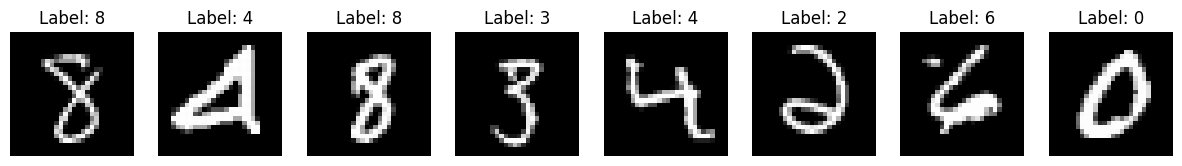

In [ ]:
fig, axes = plt.subplots(1, 8, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')  # grayscale
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')

plt.show()


In [ ]:
import torch
import torch.nn as nn

# ----- Teacher Model (2 hidden layers) -----
class TeacherMLP(nn.Module):
    def __init__(self, hidden1=512, hidden2=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 10)  # 10 output classes (digits)
        )
    def forward(self, x):
        return self.net(x)

In [ ]:
# Create instances
teacher = TeacherMLP(hidden1=512, hidden2=256)

In [ ]:
print(teacher)

TeacherMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [ ]:
# ----- Train Teacher -----
def train_teacher(model, loader, epochs=1, lr=1e-3):

    opt = optim.Adam(model.parameters(), lr=lr)

    loss_fn = nn.CrossEntropyLoss()

    model.train()

    for ep in range(epochs):
        total_loss = 0
        for x, y in loader:
            opt.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            opt.step()
            total_loss += loss.item()
        print(f"Teacher Epoch {ep+1}: Loss = {total_loss/len(loader):.4f}")

In [ ]:
train_teacher(teacher, train_loader)

Teacher Epoch 1: Loss = 0.3027


In [ ]:
print(teacher.state_dict())


OrderedDict([('net.1.weight', tensor([[-0.0226,  0.0012, -0.0154,  ..., -0.0175, -0.0362, -0.0267],
        [-0.0119, -0.0141, -0.0230,  ...,  0.0003,  0.0189,  0.0281],
        [ 0.0184,  0.0174, -0.0294,  ...,  0.0196,  0.0083, -0.0079],
        ...,
        [ 0.0385,  0.0217,  0.0104,  ..., -0.0297, -0.0022,  0.0197],
        [-0.0067, -0.0302, -0.0067,  ..., -0.0211, -0.0273, -0.0380],
        [-0.0181, -0.0165, -0.0014,  ...,  0.0462,  0.0410, -0.0159]])), ('net.1.bias', tensor([ 0.0327,  0.0078,  0.0153,  0.0101, -0.0207,  0.0004, -0.0036, -0.0052,
        -0.0372, -0.0105, -0.0349, -0.0190, -0.0225,  0.0172,  0.0063, -0.0016,
        -0.0292, -0.0367,  0.0319,  0.0065, -0.0353, -0.0167, -0.0175, -0.0036,
        -0.0350, -0.0036, -0.0281,  0.0069,  0.0109,  0.0164, -0.0116,  0.0093,
         0.0014, -0.0309,  0.0250, -0.0049, -0.0204, -0.0078,  0.0299, -0.0253,
        -0.0145,  0.0215, -0.0091,  0.0277, -0.0342, -0.0293, -0.0042,  0.0091,
         0.0270,  0.0273, -0.0002, -0.0

In [ ]:
# # ----- Freeze Teacher -----
# for param in teacher.parameters():
#     param.requires_grad = False
# teacher.eval()
# print("Teacher model trained and frozen.")

In [ ]:
# ----- Student Model (1 hidden layer) -----
class StudentMLP(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 10)  # smaller model, only 1 hidden layer
        )
    def forward(self, x):
        return self.net(x)

In [ ]:
student = StudentMLP(hidden=128)

In [ ]:
print(student)

StudentMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
# (A) Pretrain student on hard labels (optional warm-up)
def pretrain_student(student, loader, epochs=1, lr=1e-3):
    student.train()
    opt = optim.Adam(student.parameters(), lr=lr)
    ce_loss = nn.CrossEntropyLoss()
    for ep in range(epochs):
        for x, y in loader:
            opt.zero_grad()
            out = student(x)
            loss = ce_loss(out, y)
            loss.backward()
            opt.step()

In [ ]:
pretrain_student(student, train_loader, epochs=1)  # optional warm-up

In [ ]:
# ----- Distillation Training -----
temperature = 2.0
alpha = 0.7
ce_loss = nn.CrossEntropyLoss()
kl_loss = nn.KLDivLoss(reduction="batchmean")
optimizer = optim.Adam(student.parameters(), lr=1e-3)

In [ ]:
def distill(student, teacher, loader, epochs=1):
    for ep in range(epochs):

        student.train()

        total_loss = 0

        for x, y in loader:
            # Teacher outputs
            with torch.no_grad():
                t_logits = teacher(x)
                t_probs = torch.softmax(t_logits / temperature, dim=1)

            # Student outputs
            s_logits = student(x)
            s_log_probs = torch.log_softmax(s_logits / temperature, dim=1)

            # Losses
            loss_soft = kl_loss(s_log_probs, t_probs) * (temperature**2)
            loss_hard = ce_loss(s_logits, y)
            loss = alpha * loss_soft + (1 - alpha) * loss_hard

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            total_loss += loss.item()
        print(f"Student Epoch {ep+1}: Loss = {total_loss/len(loader):.4f}")

In [ ]:
# # (B) Then run your existing distill(...)
# distill(student, teacher, train_loader, epochs=3)

In [ ]:
distill(student, teacher, train_loader)

Student Epoch 1: Loss = 0.1682


In [ ]:
# ----- 5. Evaluation Function -----
def evaluate(model, loader, name="Model"):
    model.eval()

    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            out = model(x)
            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    acc = correct / total * 100
    print(f"{name} Accuracy: {acc:.2f}%")
    return acc

In [ ]:
# Evaluate both Teacher and Student
evaluate(teacher, test_loader, "Teacher")

Teacher Accuracy: 94.20%


94.19999999999999

In [ ]:
evaluate(student, test_loader, "Student")

Student Accuracy: 94.21%


94.21000000000001

In [ ]:
# ----- 6. Sample Predictions -----
def predict(model, x):
    model.eval()
    with torch.no_grad():
        out = model(x)
        return out.argmax(dim=1)

In [ ]:
sample_batch, sample_labels = next(iter(test_loader))

In [ ]:
preds = predict(student, sample_batch)

In [ ]:
print("Sample predictions (Student):", preds[:20])

Sample predictions (Student): tensor([7, 2, 1, 0, 4, 1, 4, 9, 6, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4])


In [ ]:
print("True labels:", sample_labels[:20])

True labels: tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4])
